# PREPROCESSING DATA NTHUD

# Library Yang Dibutuhkan

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import torch
import torchvision
import hashlib
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(f" PyTorch Version: {torch.__version__}")
print(f" Torchvision Version: {torchvision.__version__}")
print(f" CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU Device: {torch.cuda.get_device_name(0)}")

 PyTorch Version: 2.7.1+cu118
 Torchvision Version: 0.22.1+cu118
 CUDA Available: True
 GPU Device: NVIDIA GeForce RTX 3060


# Pembagian Data: Subject-Independent Split

Dataset NTHUDDD2 dibagi berdasarkan **ID Subjek**, bukan secara acak (random split).
Pendekatan ini disebut **Subject-Independent Split** — setiap orang hanya muncul
di SATU split saja, sehingga model tidak bisa "menghafal wajah" dan benar-benar 
harus belajar generalisasi kondisi mata.

Pembagian subjek:
- **Train** : Subjek 001, 005
- **Val**   : Subjek 002
- **Test**  : Subjek 006

Rasio yang dihasilkan (~61:28:10) bukan angka bulat yang dipilih secara manual,
melainkan **konsekuensi alami** dari jumlah frame per subjek di dataset. 
Ini justru lebih valid secara ilmiah dibandingkan random split.

In [2]:
def parse_subject_id(filename):
    base = os.path.splitext(os.path.basename(filename))[0]
    parts = base.split("_")
    return parts[0] if len(parts) > 0 else base

def split_dataset_nthu_final(source_dir, dest_dir):
    VAL_IDS  = ['002']
    TEST_IDS = ['006']
    # Subjek '001' dan '005' otomatis masuk TRAIN
    
    classes = sorted([d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))])
    if not classes:
        print(" [!] Tidak menemukan folder kelas.")
        return

    splits_list = ["train", "val", "test"]
    for split in splits_list:
        for cls in classes:
            os.makedirs(os.path.join(dest_dir, split, cls), exist_ok=True)

    print(f"Mulai memproses dataset dari: {source_dir}")
    print(f"Hasil akan disimpan di       : {dest_dir}\n")

    counts = Counter()
    for cls in classes:
        cls_dir = os.path.join(source_dir, cls)
        files = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg",".jpeg",".png"))]
        print(f"Memproses kelas {cls} ({len(files)} gambar)...")
        for f in files:
            subj_id = parse_subject_id(f)
            if subj_id in TEST_IDS:
                target_split = "test"
            elif subj_id in VAL_IDS:
                target_split = "val"
            else:
                target_split = "train"
            shutil.copy2(os.path.join(cls_dir, f), os.path.join(dest_dir, target_split, cls, f))
            counts[target_split] += 1

    total_all = sum(counts.values())
    print("\n" + "="*55)
    print(f"{'LAPORAN AKHIR SPLIT DATASET NTHUDDD2':^55}")
    print("="*55)
    for s in splits_list:
        perc = (counts[s]/total_all)*100
        print(f" {s.upper():5} SET : {counts[s]:6} gambar ({perc:.2f}%)")
    print("-"*55)
    print(f" TOTAL DATA : {total_all} gambar")
    print("="*55)

def verify_nthu_leakage(dest_dir):
    splits = ["train", "val", "test"]
    split_groups = {}
    for s in splits:
        ids = set()
        for root, dirs, files in os.walk(os.path.join(dest_dir, s)):
            for f in files:
                if f.lower().endswith((".jpg", ".png", ".jpeg")):
                    ids.add(parse_subject_id(f))
        split_groups[s] = ids

    print("\n=== VERIFIKASI SUBJEK (ANTI LEAKAGE) ===")
    print(f"Subjek di Train : {split_groups['train']} (Total: {len(split_groups['train'])})")
    print(f"Subjek di Val   : {split_groups['val']} (Total: {len(split_groups['val'])})")
    print(f"Subjek di Test  : {split_groups['test']} (Total: {len(split_groups['test'])})")

    leak = (split_groups["train"] & split_groups["val"]) | \
           (split_groups["train"] & split_groups["test"]) | \
           (split_groups["val"] & split_groups["test"])
    if not leak:
        print("\n[STATUS] AMAN 100%! Tidak ada subjek yang bocor antar folder.")
    else:
        print(f"\n[WARNING] Terjadi kebocoran subjek: {leak}")

# =====================================================================
source_dataset = r"C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2"
dest_dataset   = r"C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT"

if os.path.exists(dest_dataset):
    print(f"Menghapus folder lama: {dest_dataset}")
    shutil.rmtree(dest_dataset)

split_dataset_nthu_final(source_dataset, dest_dataset)
verify_nthu_leakage(dest_dataset)

Menghapus folder lama: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT
Mulai memproses dataset dari: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2
Hasil akan disimpan di       : C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT

Memproses kelas drowsy (36034 gambar)...
Memproses kelas notdrowsy (30491 gambar)...

         LAPORAN AKHIR SPLIT DATASET NTHUDDD2          
 TRAIN SET :  40949 gambar (61.55%)
 VAL   SET :  18833 gambar (28.31%)
 TEST  SET :   6743 gambar (10.14%)
-------------------------------------------------------
 TOTAL DATA : 66525 gambar

=== VERIFIKASI SUBJEK (ANTI LEAKAGE) ===
Subjek di Train : {'005', '001'} (Total: 2)
Subjek di Val   : {'002'} (Total: 1)
Subjek di Test  : {'006'} (Total: 1)

[STATUS] AMAN 100%! Tidak ada subjek yang bocor antar folder.


# Konfigurasi Path Dataset

In [3]:
DATASET_ROOT = r"C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT" 

# Path untuk setiap split
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")
TEST_DIR = os.path.join(DATASET_ROOT, "test")

# Nama kelas (folder di dalam train/val/test)
CLASS_NAMES = ["notdrowsy", "drowsy"]  

# Cek apakah folder-folder ini ada
print(" Memeriksa struktur folder dataset...\n")

for split_name, split_path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    if os.path.exists(split_path):
        print(f" {split_name} folder ditemukan: {split_path}")
        for class_name in CLASS_NAMES:
            class_path = os.path.join(split_path, class_name)
            if os.path.exists(class_path):
                print(f"   ├─  Kelas '{class_name}' ditemukan")
            else:
                print(f"   ├─  Kelas '{class_name}' TIDAK DITEMUKAN!")
    else:
        print(f" {split_name} folder TIDAK DITEMUKAN: {split_path}")

print("\n" + "="*60)


 Memeriksa struktur folder dataset...

 Train folder ditemukan: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\train
   ├─  Kelas 'notdrowsy' ditemukan
   ├─  Kelas 'drowsy' ditemukan
 Val folder ditemukan: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\val
   ├─  Kelas 'notdrowsy' ditemukan
   ├─  Kelas 'drowsy' ditemukan
 Test folder ditemukan: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\test
   ├─  Kelas 'notdrowsy' ditemukan
   ├─  Kelas 'drowsy' ditemukan



# Cek dan Hapus File Corrupt

In [9]:
def check_and_remove_corrupt_images(base_dir, class_names):
    corrupt_files = []
    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            continue
        print(f"\n Memeriksa: {class_path}")
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            if not os.path.isfile(file_path):
                continue
            try:
                img = Image.open(file_path)
                img.verify()
                img = Image.open(file_path)
                img.load()
            except Exception as e:
                print(f"   [CORRUPT] {filename} → {str(e)}")
                corrupt_files.append(file_path)
                try:
                    os.remove(file_path)
                    print(f"   [DIHAPUS] {filename}")
                except Exception as del_err:
                    print(f"   [GAGAL HAPUS] {str(del_err)}")
    return corrupt_files

print(" MEMULAI PENGECEKAN FILE CORRUPT...\n")
all_corrupt = []
for split_name, split_path in splits.items():
    print(f"\n{'='*60}\n SPLIT: {split_name.upper()}\n{'='*60}")
    corrupt = check_and_remove_corrupt_images(split_path, CLASS_NAMES)
    all_corrupt.extend(corrupt)

print(f"\n{'='*60}")
print(f" Total corrupt ditemukan & dihapus: {len(all_corrupt)}")
print(" SEMUA FILE DALAM KONDISI BAIK!" if not all_corrupt else " Ada file corrupt, cek log di atas.")
print("="*60)

 MEMULAI PENGECEKAN FILE CORRUPT...


 SPLIT: TRAIN

 Memeriksa: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\train\notdrowsy

 Memeriksa: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\train\drowsy

 SPLIT: VAL

 Memeriksa: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\val\notdrowsy

 Memeriksa: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\val\drowsy

 SPLIT: TEST

 Memeriksa: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\test\notdrowsy

 Memeriksa: C:\kuliah-sementara\SKRIPSI\Dataset_nthuddd2_SPLIT\test\drowsy

 Total corrupt ditemukan & dihapus: 0
 SEMUA FILE DALAM KONDISI BAIK!


#  DISTRIBUSI KELAS DATASET

In [10]:

def calculate_dataset_stats(base_dir, class_names):
    """
    Menghitung jumlah gambar dalam setiap kelas di sebuah direktori.
    """
    stats = {}
    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        if os.path.exists(class_path):
            files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
            stats[class_name] = len(files)
        else:
            stats[class_name] = 0
            
    return stats

print(" DISTRIBUSI KELAS DATASET\n")
print("="*60)

total_all = 0
split_stats = {}

for split_name, split_path in splits.items():
    stats = calculate_dataset_stats(split_path, CLASS_NAMES)
    split_stats[split_name] = stats
    
    total = sum(stats.values())
    total_all += total
    
    print(f"\n SPLIT: {split_name.upper()}")
    print("-" * 30)
    print(f"   ├─ notdrowsy: {stats.get('notdrowsy', 0):,} gambar")
    print(f"   ├─ drowsy: {stats.get('drowsy', 0):,} gambar")
    print(f"   └─ Total {split_name}: {total:,} gambar")
    
    if total > 0:
        notdrowsy_ratio = (stats.get('notdrowsy', 0) / total) * 100
        drowsy_ratio = (stats.get('drowsy', 0) / total) * 100
        print(f"      Balance: {notdrowsy_ratio:.2f}% notdrowsy | {drowsy_ratio:.2f}% drowsy")

print("\n" + "="*60)
print(f" TOTAL KESELURUHAN DATASET: {total_all:,} gambar")
print("="*60)


 DISTRIBUSI KELAS DATASET


 SPLIT: TRAIN
------------------------------
   ├─ notdrowsy: 18,278 gambar
   ├─ drowsy: 22,671 gambar
   └─ Total Train: 40,949 gambar
      Balance: 44.64% notdrowsy | 55.36% drowsy

 SPLIT: VAL
------------------------------
   ├─ notdrowsy: 8,237 gambar
   ├─ drowsy: 10,596 gambar
   └─ Total Val: 18,833 gambar
      Balance: 43.74% notdrowsy | 56.26% drowsy

 SPLIT: TEST
------------------------------
   ├─ notdrowsy: 3,976 gambar
   ├─ drowsy: 2,767 gambar
   └─ Total Test: 6,743 gambar
      Balance: 58.96% notdrowsy | 41.04% drowsy

 TOTAL KESELURUHAN DATASET: 66,525 gambar


# Cek Resolusi Gambar

Sebelum masuk ke pipeline MediaPipe, penting untuk memastikan tidak ada gambar
dengan resolusi terlalu kecil. MediaPipe FaceMesh membutuhkan gambar minimal
sekitar 50×50 piksel agar dapat mendeteksi landmark wajah dengan baik.

Gambar yang terlalu kecil akan menyebabkan kegagalan deteksi dan berakhir sebagai
frame yang di-drop di Notebook 06.

In [11]:
from tqdm import tqdm

def check_image_resolutions(base_dir, class_names, min_size=50, sample_limit=500):
    """
    Mengecek resolusi gambar di seluruh split.
    Melaporkan min/max/mean resolusi dan jumlah gambar di bawah min_size.
    sample_limit: batasi sampel per folder agar tidak terlalu lama
    """
    all_widths, all_heights, too_small = [], [], []

    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.exists(class_path):
            continue

        files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))][:sample_limit]

        for fname in files:
            fpath = os.path.join(class_path, fname)
            try:
                img = Image.open(fpath)
                w, h = img.size
                all_widths.append(w)
                all_heights.append(h)
                if w < min_size or h < min_size:
                    too_small.append((fpath, w, h))
            except:
                pass

    return all_widths, all_heights, too_small

print(" CEK RESOLUSI GAMBAR (Sampel per folder: 500)\n")
print("="*60)

for split_name, split_path in splits.items():
    widths, heights, too_small = check_image_resolutions(split_path, CLASS_NAMES)

    if not widths:
        print(f"\n {split_name}: Tidak ada gambar ditemukan.")
        continue

    print(f"\n SPLIT: {split_name.upper()}")
    print(f"   Width  → Min: {min(widths)}px | Max: {max(widths)}px | Mean: {np.mean(widths):.0f}px")
    print(f"   Height → Min: {min(heights)}px | Max: {max(heights)}px | Mean: {np.mean(heights):.0f}px")
    print(f"   Gambar < 50px: {len(too_small)} gambar", end="")

    if too_small:
        print(f"   PERLU DIPERHATIKAN")
        for path, w, h in too_small[:3]:
            print(f"      - {os.path.basename(path)} ({w}×{h})")
    else:
        print("  AMAN")

print("\n" + "="*60)

 CEK RESOLUSI GAMBAR (Sampel per folder: 500)


 SPLIT: TRAIN
   Width  → Min: 640px | Max: 640px | Mean: 640px
   Height → Min: 480px | Max: 480px | Mean: 480px
   Gambar < 50px: 0 gambar  AMAN

 SPLIT: VAL
   Width  → Min: 640px | Max: 640px | Mean: 640px
   Height → Min: 480px | Max: 480px | Mean: 480px
   Gambar < 50px: 0 gambar  AMAN

 SPLIT: TEST
   Width  → Min: 640px | Max: 640px | Mean: 640px
   Height → Min: 480px | Max: 480px | Mean: 480px
   Gambar < 50px: 0 gambar  AMAN



# Cek Duplikasi Konten (MD5 Hash)

Pengecekan apakah ada gambar dengan **konten identik** (byte-for-byte sama)
yang tersebar di folder yang berbeda (Train vs Val, Train vs Test).
Jika ditemukan, file di Val/Test akan dihapus untuk menjaga integritas evaluasi.

In [12]:
def calculate_md5(file_path):
    """Menghitung MD5 hash dari sebuah file gambar."""
    hash_md5 = hashlib.md5()
    try:
        with open(file_path, "rb") as f:
            for chunk in iter(lambda: f.read(4096), b""):
                hash_md5.update(chunk)
        return hash_md5.hexdigest()
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

def find_and_remove_duplicates(train_dir, val_dir, test_dir):
    """
    Mencari dan MENGHAPUS gambar duplikat antar folder split.
    Prioritas Hapus: Hapus file di Test/Val, pertahankan file di Train.
    """
    print(" SEDANG MEMERIKSA & MEMBERSIHKAN DUPLIKASI KONTEN...")
    print("   (Proses ini mungkin memakan waktu 1-2 menit...)")
    
    train_hashes = {}
    val_hashes = {}
    test_hashes = {}
    
    def fill_hashes(directory, hash_dict, label):
        print(f"    Memproses {label} set...")
        count = 0
        for root, _, files in os.walk(directory):
            for file in files:
                if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                    path = os.path.join(root, file)
                    file_hash = calculate_md5(path)
                    if file_hash:
                        hash_dict[file_hash] = path
                        count += 1
        return count

    # 1. Hitung Hash
    fill_hashes(train_dir, train_hashes, "TRAIN")
    fill_hashes(val_dir, val_hashes, "VAL")
    fill_hashes(test_dir, test_hashes, "TEST")
    
    # 2. Cek Irisan & Hapus
    train_keys = set(train_hashes.keys())
    val_keys = set(val_hashes.keys())
    test_keys = set(test_hashes.keys())
    
    leak_train_test = train_keys.intersection(test_keys)
    leak_train_val = train_keys.intersection(val_keys)
    
    print("\n HASIL PEMBERSIHAN:")
    print("="*60)
    
    # Hapus Duplikat Train vs Test (Hapus yang di Test)
    if leak_train_test:
        print(f" Ditemukan {len(leak_train_test)} duplikat di TRAIN & TEST. Menghapus file di TEST...")
        for h in leak_train_test:
            file_to_remove = test_hashes[h]
            try:
                os.remove(file_to_remove)
                print(f"    Dihapus: {file_to_remove}")
            except Exception as e:
                print(f"    Gagal hapus {file_to_remove}: {e}")
    else:
        print(" Train vs Test: AMAN (Tidak ada duplikat).")

    # Hapus Duplikat Train vs Val (Hapus yang di Val)
    if leak_train_val:
        print(f" Ditemukan {len(leak_train_val)} duplikat di TRAIN & VAL. Menghapus file di VAL...")
        for h in leak_train_val:
            file_to_remove = val_hashes[h]
            try:
                os.remove(file_to_remove)
                print(f"    Dihapus: {file_to_remove}")
            except Exception as e:
                print(f"    Gagal hapus {file_to_remove}: {e}")
    else:
        print(" Train vs Val: AMAN (Tidak ada duplikat).")
        
    print("="*60)
    print(" Dataset sekarang sudah BERSIH dan VALID!")

# Jalankan Fungsi
find_and_remove_duplicates(TRAIN_DIR, VAL_DIR, TEST_DIR)


 SEDANG MEMERIKSA & MEMBERSIHKAN DUPLIKASI KONTEN...
   (Proses ini mungkin memakan waktu 1-2 menit...)
    Memproses TRAIN set...
    Memproses VAL set...
    Memproses TEST set...

 HASIL PEMBERSIHAN:
 Train vs Test: AMAN (Tidak ada duplikat).
 Train vs Val: AMAN (Tidak ada duplikat).
 Dataset sekarang sudah BERSIH dan VALID!


# Cek Data Leakage Antar Split (Berdasarkan Nama File)

Pengecekan apakah ada **frame yang sama persis** (nama file identik) yang
tersebar di split yang berbeda. Karena split dilakukan berdasarkan ID subjek,
setiap subjek hanya ada di satu split — sehingga frame yang sama tidak mungkin
muncul di dua split sekaligus.

In [13]:
def check_data_leakage_by_filename(train_dir, val_dir, test_dir):
    print(" MEMERIKSA DATA LEAKAGE (Berdasarkan Nama File)...")
    print("="*60)

    def get_all_filenames(directory):
        filenames, count = set(), 0
        for root, _, files in os.walk(directory):
            for file in files:
                if file.lower().endswith(('.jpg','.png','.jpeg')):
                    filenames.add(file)
                    count += 1
        return filenames, count

    train_files, n_train = get_all_filenames(train_dir)
    val_files,   n_val   = get_all_filenames(val_dir)
    test_files,  n_test  = get_all_filenames(test_dir)

    print(f" Jumlah Gambar di Train : {n_train}")
    print(f" Jumlah Gambar di Val   : {n_val}")
    print(f" Jumlah Gambar di Test  : {n_test}")

    leak_tt = train_files & test_files
    leak_tv = train_files & val_files

    print("\n HASIL ANALISIS LEAKAGE:")

    if leak_tt:
        print(f"   Train vs Test: {len(leak_tt)} frame identik ditemukan!")
        print(f"    Contoh: {list(leak_tt)[:3]}")
    else:
        print("  Train vs Test: AMAN — Tidak ada frame yang sama.")

    if leak_tv:
        print(f"   Train vs Val: {len(leak_tv)} frame identik ditemukan!")
    else:
        print("  Train vs Val : AMAN — Tidak ada frame yang sama.")

    print("="*60)
    print(" KESIMPULAN AKHIR:")
    if not leak_tt and not leak_tv:
        #  DIPERBAIKI: kalimat lama salah karena menyebut "subjek sama di berbagai split"
        # Padahal split ini adalah subject-independent — setiap subjek HANYA ada di satu split.
        print(" Dataset VALID dengan Subject-Independent Split.")
        print(" Setiap subjek hanya muncul di SATU split, dan tidak ada")
        print(" frame yang bocor antar Train/Val/Test.")
        print(" Model dipaksa belajar generalisasi, bukan menghafal identitas subjek.")
    else:
        print("   Masih ada duplikasi. Jalankan ulang cell Cek Duplikasi di atas.")

check_data_leakage_by_filename(TRAIN_DIR, VAL_DIR, TEST_DIR)

 MEMERIKSA DATA LEAKAGE (Berdasarkan Nama File)...
 Jumlah Gambar di Train : 40949
 Jumlah Gambar di Val   : 18833
 Jumlah Gambar di Test  : 6743

 HASIL ANALISIS LEAKAGE:
  Train vs Test: AMAN — Tidak ada frame yang sama.
  Train vs Val : AMAN — Tidak ada frame yang sama.
 KESIMPULAN AKHIR:
 Dataset VALID dengan Subject-Independent Split.
 Setiap subjek hanya muncul di SATU split, dan tidak ada
 frame yang bocor antar Train/Val/Test.
 Model dipaksa belajar generalisasi, bukan menghafal identitas subjek.


# Visualisasi Sampel Gambar dari Dataset

Menampilkan contoh gambar dari masing-masing kelas (drowsy & notdrowsy)
dari folder Train untuk memverifikasi secara visual bahwa dataset sudah
terbaca dengan benar.

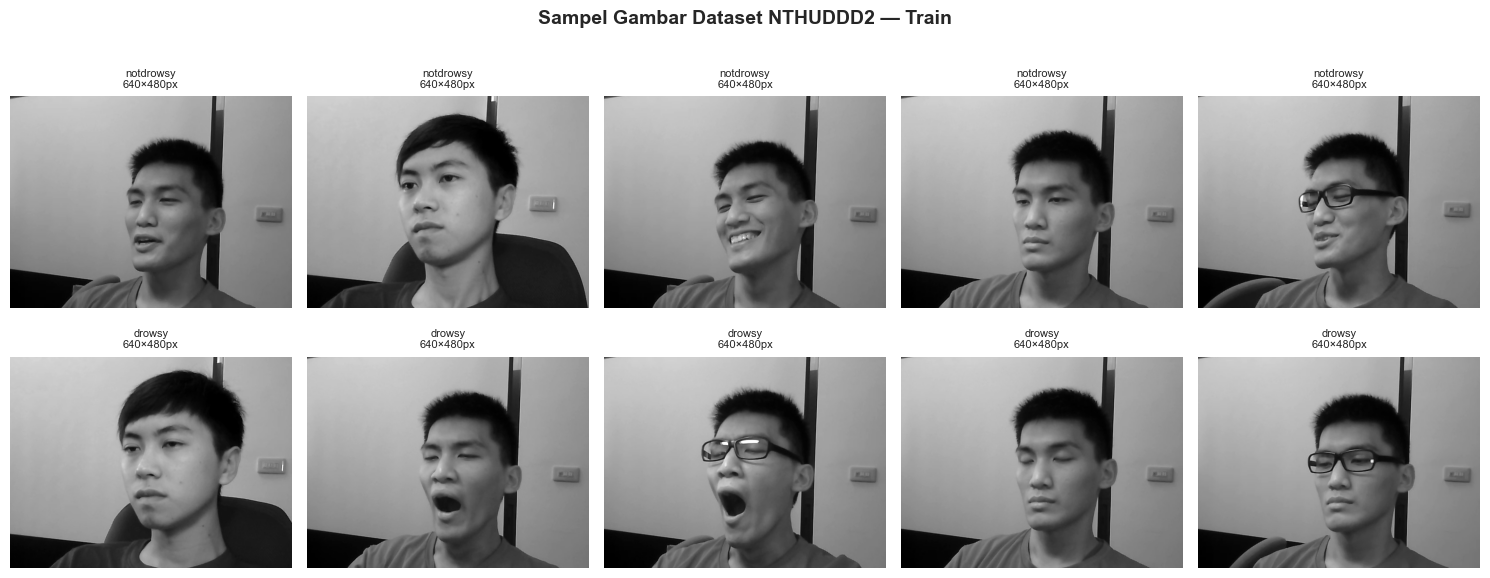

In [14]:
def show_sample_images(base_dir, class_names, n_samples=5, split_name="Train"):
    fig, axes = plt.subplots(len(class_names), n_samples,
                             figsize=(n_samples * 3, len(class_names) * 3))
    fig.suptitle(f"Sampel Gambar Dataset NTHUDDD2 — {split_name}",
                 fontsize=14, fontweight='bold', y=1.01)

    for row_idx, class_name in enumerate(class_names):
        class_path = os.path.join(base_dir, class_name)
        files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]

        import random
        samples = random.sample(files, min(n_samples, len(files)))

        for col_idx, fname in enumerate(samples):
            img_path = os.path.join(class_path, fname)
            img      = Image.open(img_path).convert("RGB")
            ax       = axes[row_idx][col_idx]
            ax.imshow(img)
            ax.set_title(f"{class_name}\n{img.size[0]}×{img.size[1]}px",
                         fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Tampilkan dari folder Train
show_sample_images(TRAIN_DIR, CLASS_NAMES, n_samples=5, split_name="Train")